<a href="https://colab.research.google.com/github/shijithpulikkal/Exploratory-Data-Analysis/blob/main/08_weather_climate_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv(
    '/content/drive/My Drive/Colab Notebooks/EDA/DelhiWeatherData.csv'
)

df.head()

Mounted at /content/drive


,datetime_utc,_conds,_dewptm,_fog,_hail,_heatindexm,_hum,_precipm,_pressurem,_rain,_snow,_tempm,_thunder,_tornado,_vism,_wdird,_wdire,_wgustm,_windchillm,_wspdm
0,19961101-11:00,Smoke,9.0,0,0,NaN,27.0,NaN,1010.0,0,0,30.0,0,0,5.0,280.0,West,NaN,NaN,7.4
1,19961101-12:00,Smoke,10.0,0,0,NaN,32.0,NaN,-9999.0,0,0,28.0,0,0,NaN,0.0,North,NaN,NaN,NaN
2,19961101-13:00,Smoke,11.0,0,0,NaN,44.0,NaN,-9999.0,0,0,24.0,0,0,NaN,0.0,North,NaN,NaN,NaN
3,19961101-14:00,Smoke,10.0,0,0,NaN,41.0,NaN,1010.0,0,0,24.0,0,0,2.0,0.0,North,NaN,NaN,NaN
4,19961101-16:00,Smoke,11.0,0,0,NaN,47.0,NaN,1011.0,0,0,23.0,0,0,1.2,0.0,North,NaN,NaN,0.0


In [3]:
df.shape

(100990, 20)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100990 entries, 0 to 100989
Data columns (total 20 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   datetime_utc  100990 non-null  object 
 1    _conds       100918 non-null  object 
 2    _dewptm      100369 non-null  float64
 3    _fog         100990 non-null  int64  
 4    _hail        100990 non-null  int64  
 5    _heatindexm  29155 non-null   float64
 6    _hum         100233 non-null  float64
 7    _precipm     0 non-null       float64
 8    _pressurem   100758 non-null  float64
 9    _rain        100990 non-null  int64  
 10   _snow        100990 non-null  int64  
 11   _tempm       100317 non-null  float64
 12   _thunder     100990 non-null  int64  
 13   _tornado     100990 non-null  int64  
 14   _vism        96562 non-null   float64
 15   _wdird       86235 non-null   float64
 16   _wdire       86235 non-null   object 
 17   _wgustm      1072 non-null    float64
 18   _wi

In [5]:
df.describe()

,_dewptm,_fog,_hail,_heatindexm,_hum,_precipm,_pressurem,_rain,_snow,_tempm,_thunder,_tornado,_vism,_wdird,_wgustm,_windchillm,_wspdm
count,100369.000000,100990.000000,100990.000000,29155.000000,100233.000000,0.0,1.007580e+05,100990.000000,100990.000000,100317.000000,100990.000000,100990.00000,96562.000000,86235.000000,1072.000000,579.000000,98632.000000
mean,15.741205,0.069690,0.000129,35.651710,57.909481,NaN,1.932331e+03,0.026260,0.000010,25.451269,0.009427,0.00002,2.402774,163.549974,37.671175,5.713817,7.678463
std,7.058587,0.254625,0.011345,5.015384,23.807771,NaN,3.183786e+05,0.159908,0.003147,8.482859,0.096633,0.00445,20.746028,120.002076,6.848666,1.203290,11.932157
min,-24.000000,0.000000,0.000000,26.800000,4.000000,NaN,-9.999000e+03,0.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000,25.900000,2.100000,0.000000
25%,10.000000,0.000000,0.000000,31.700000,39.000000,NaN,1.002000e+03,0.000000,0.000000,19.000000,0.000000,0.00000,1.500000,50.000000,33.300000,4.900000,0.000000
50%,15.000000,0.000000,0.000000,35.100000,59.000000,NaN,1.008000e+03,0.000000,0.000000,27.000000,0.000000,0.00000,2.000000,160.000000,37.000000,6.100000,7.400000
75%,22.000000,0.000000,0.000000,39.200000,78.000000,NaN,1.014000e+03,0.000000,0.000000,32.000000,0.000000,0.00000,3.000000,270.000000,40.700000,6.800000,11.100000
max,75.000000,1.000000,1.000000,73.600000,243.000000,NaN,1.010614e+08,1.000000,1.000000,90.000000,1.000000,1.00000,6436.000000,960.000000,92.600000,7.300000,1514.900000


In [6]:
# Convert datetime column
df['datetime_utc'] = pd.to_datetime(df['datetime_utc'], format='%Y%m%d-%H:%M')
df[['datetime_utc']].head()

,datetime_utc
0,1996-11-01 11:00:00
1,1996-11-01 12:00:00
2,1996-11-01 13:00:00
3,1996-11-01 14:00:00
4,1996-11-01 16:00:00


**2. Data Cleaning**

In [7]:
# Check missing values
df.isnull().sum().sort_values(ascending=False)

,0
_precipm,100990
_windchillm,100411
_wgustm,99918
_heatindexm,71835
_wdire,14755
_wdird,14755
_vism,4428
_wspdm,2358
_hum,757
_tempm,673


In [10]:
# Strip whitespace from column names first
df.columns = df.columns.str.strip()
df.columns.tolist()

# Focus on key columns for this analysis
key_cols = ['datetime_utc', '_tempm', '_hum', '_pressurem', '_wspdm', '_conds']
df = df[key_cols].copy()
df.columns = ['datetime', 'temperature', 'humidity', 'pressure', 'wind_speed', 'conditions']
df.head()

,datetime,temperature,humidity,pressure,wind_speed,conditions
0,1996-11-01 11:00:00,30.0,27.0,1010.0,7.4,Smoke
1,1996-11-01 12:00:00,28.0,32.0,-9999.0,NaN,Smoke
2,1996-11-01 13:00:00,24.0,44.0,-9999.0,NaN,Smoke
3,1996-11-01 14:00:00,24.0,41.0,1010.0,NaN,Smoke
4,1996-11-01 16:00:00,23.0,47.0,1011.0,0.0,Smoke


In [9]:
df.columns.tolist()

['datetime_utc',
 ' _conds',
 ' _dewptm',
 ' _fog',
 ' _hail',
 ' _heatindexm',
 ' _hum',
 ' _precipm',
 ' _pressurem',
 ' _rain',
 ' _snow',
 ' _tempm',
 ' _thunder',
 ' _tornado',
 ' _vism',
 ' _wdird',
 ' _wdire',
 ' _wgustm',
 ' _windchillm',
 ' _wspdm']

In [11]:
# Drop rows missing core weather readings
df = df.dropna(subset=['temperature', 'humidity'])
df.shape

(100233, 6)

In [12]:
# Check for sensor error / unrealistic values
df[['temperature', 'humidity', 'pressure', 'wind_speed']].describe()

,temperature,humidity,pressure,wind_speed
count,100233.000000,100233.000000,1.000030e+05,97943.000000
mean,25.453693,57.909481,1.960076e+03,7.601373
std,8.482327,23.807771,3.195778e+05,11.566636
min,1.000000,4.000000,-9.999000e+03,0.000000
25%,19.000000,39.000000,1.002000e+03,0.000000
50%,27.000000,59.000000,1.008000e+03,7.400000
75%,32.000000,78.000000,1.014000e+03,11.100000
max,90.000000,243.000000,1.010614e+08,1514.900000


In [13]:
# Remove unrealistic temperature values (Delhi range roughly -5 to 50 C)
df = df[(df['temperature'] > -10) & (df['temperature'] < 55)]

# Humidity must be 0-100
df = df[(df['humidity'] >= 0) & (df['humidity'] <= 100)]

# Pressure - realistic range roughly 900-1100 hPa, treat outliers as missing
df.loc[(df['pressure'] < 900) | (df['pressure'] > 1100), 'pressure'] = np.nan

# Wind speed - remove negative/extreme values
df.loc[(df['wind_speed'] < 0) | (df['wind_speed'] > 100), 'wind_speed'] = np.nan

df.shape

(100226, 6)

In [14]:
# Check duplicates
df = df.drop_duplicates()
df.shape

(100226, 6)

In [15]:
# Extract year, month, season
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

df['season'] = df['month'].apply(get_season)
df[['datetime', 'year', 'month', 'season']].head()

,datetime,year,month,season
0,1996-11-01 11:00:00,1996,11,Post-Monsoon
1,1996-11-01 12:00:00,1996,11,Post-Monsoon
2,1996-11-01 13:00:00,1996,11,Post-Monsoon
3,1996-11-01 14:00:00,1996,11,Post-Monsoon
4,1996-11-01 16:00:00,1996,11,Post-Monsoon


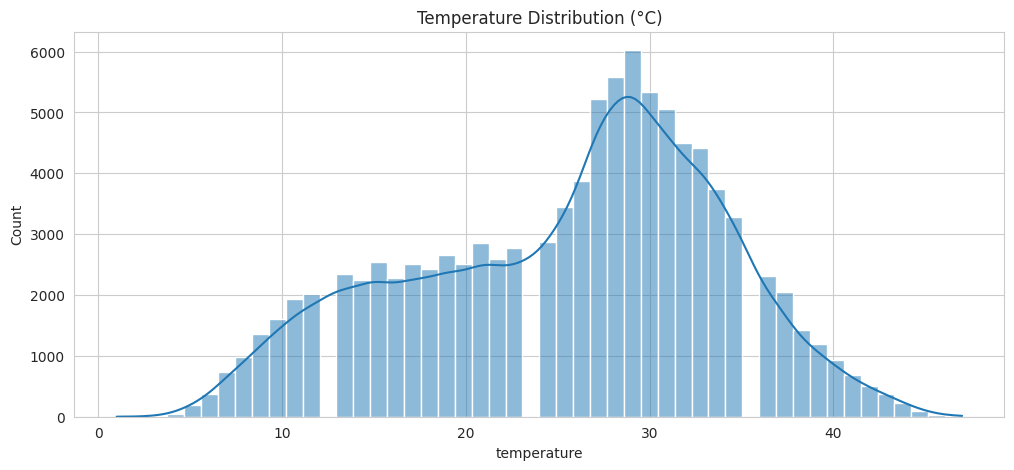

In [16]:
# Temperature distribution
plt.figure(figsize=(12,5))
sns.histplot(df['temperature'], bins=50, kde=True)
plt.title('Temperature Distribution (°C)')
plt.show()

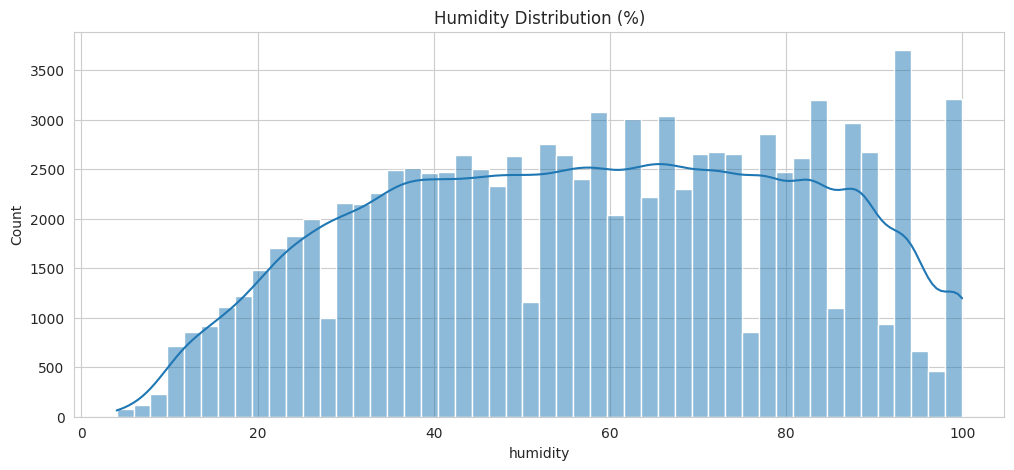

In [17]:
# Humidity distribution
plt.figure(figsize=(12,5))
sns.histplot(df['humidity'], bins=50, kde=True)
plt.title('Humidity Distribution (%)')
plt.show()

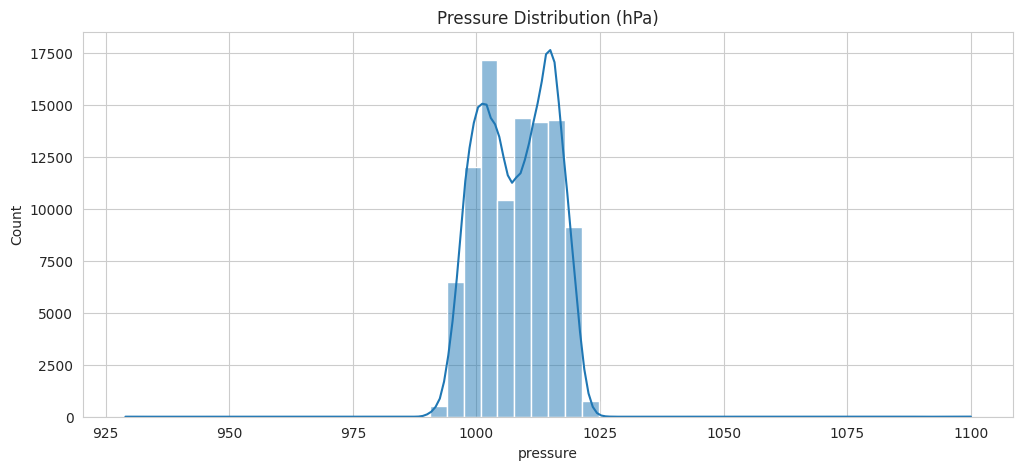

In [18]:
# Pressure distribution
plt.figure(figsize=(12,5))
sns.histplot(df['pressure'].dropna(), bins=50, kde=True)
plt.title('Pressure Distribution (hPa)')
plt.show()

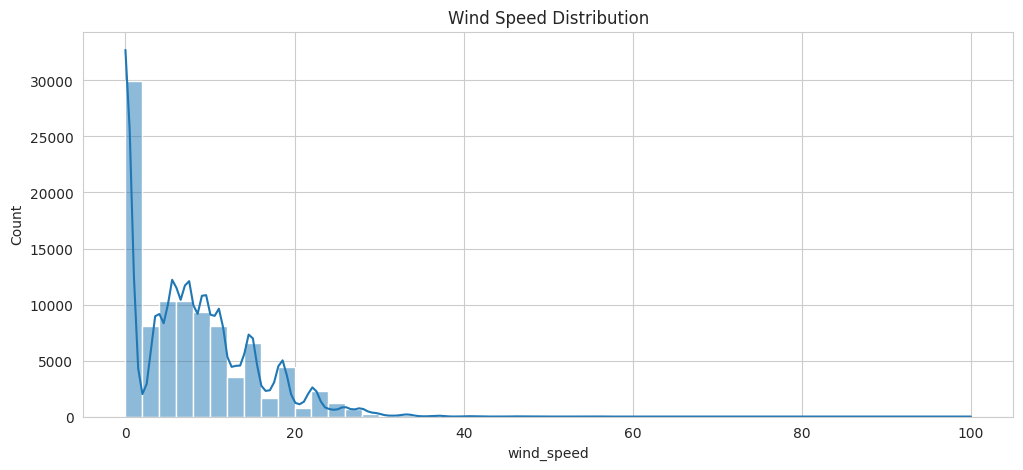

In [19]:
# Wind speed distribution
plt.figure(figsize=(12,5))
sns.histplot(df['wind_speed'].dropna(), bins=50, kde=True)
plt.title('Wind Speed Distribution')
plt.show()

**4. Time Series / Seasonal Analysis**

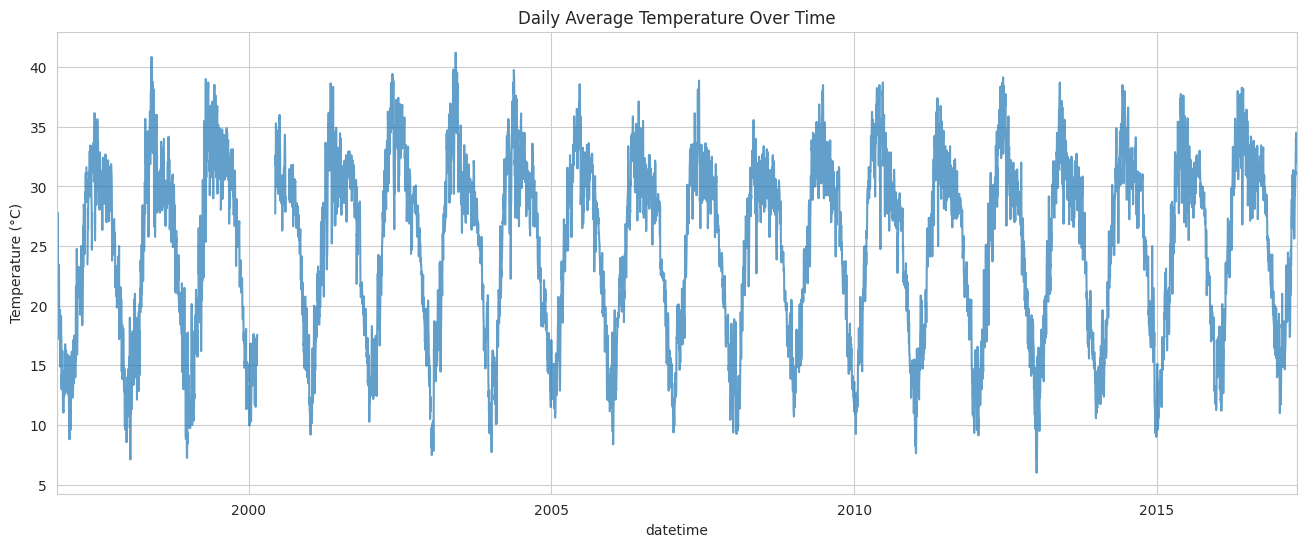

In [20]:
# Daily average temperature over full time range
daily_temp = df.set_index('datetime').resample('D')['temperature'].mean()

plt.figure(figsize=(16,6))
daily_temp.plot(alpha=0.7)
plt.title('Daily Average Temperature Over Time')
plt.ylabel('Temperature (°C)')
plt.show()

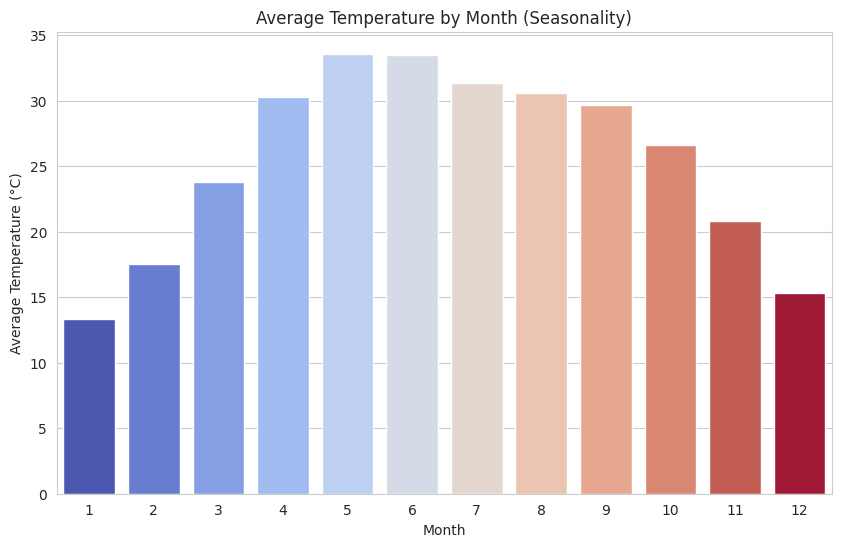

In [21]:
# Average temperature by month - seasonality
monthly_avg_temp = df.groupby('month')['temperature'].mean()

plt.figure(figsize=(10,6))
sns.barplot(x=monthly_avg_temp.index, y=monthly_avg_temp.values, hue=monthly_avg_temp.index, palette='coolwarm', legend=False)
plt.title('Average Temperature by Month (Seasonality)')
plt.xlabel('Month')
plt.ylabel('Average Temperature (°C)')
plt.show()

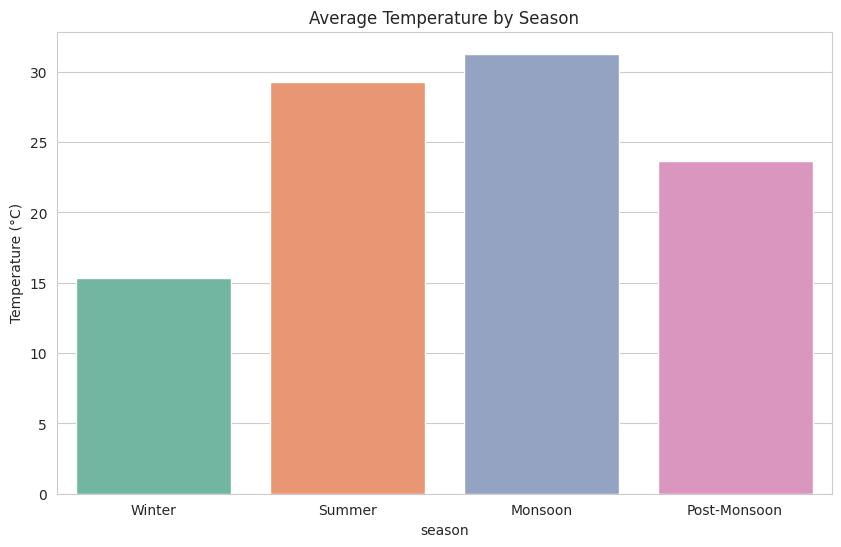

In [22]:
# Average temperature by season
season_order = ['Winter', 'Summer', 'Monsoon', 'Post-Monsoon']
season_avg = df.groupby('season')['temperature'].mean().reindex(season_order)

sns.barplot(x=season_avg.index, y=season_avg.values, hue=season_avg.index, palette='Set2', legend=False)
plt.title('Average Temperature by Season')
plt.ylabel('Temperature (°C)')
plt.show()

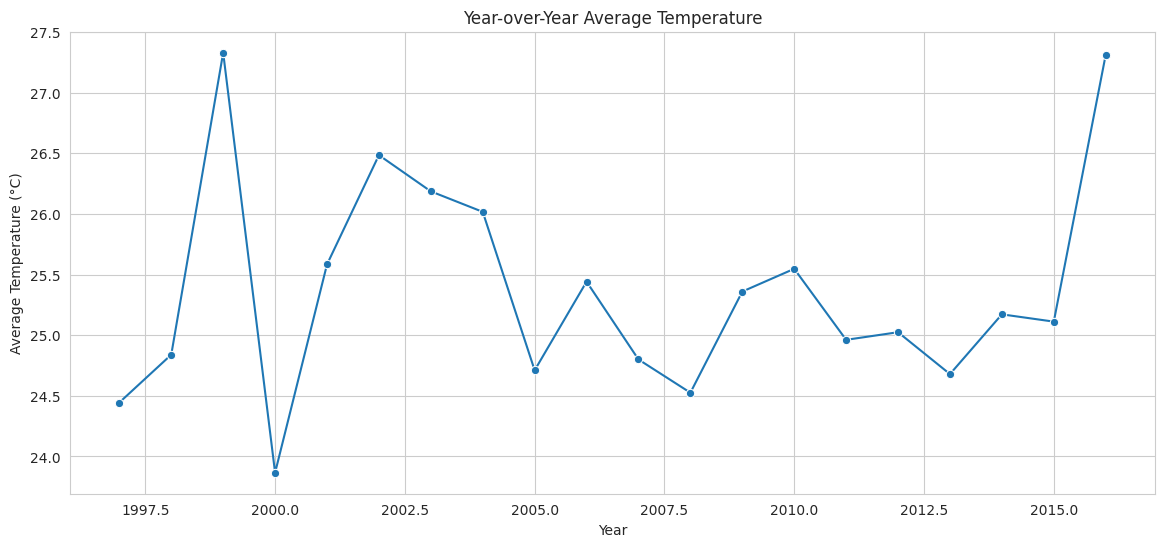

In [23]:
# Year-over-year average temperature comparison
yearly_avg_temp = df.groupby('year')['temperature'].mean()
yearly_avg_temp = yearly_avg_temp[(yearly_avg_temp.index >= yearly_avg_temp.index.min()+1) &
                                     (yearly_avg_temp.index <= yearly_avg_temp.index.max()-1)]
# trims potentially incomplete first/last years

plt.figure(figsize=(14,6))
sns.lineplot(x=yearly_avg_temp.index, y=yearly_avg_temp.values, marker='o')
plt.title('Year-over-Year Average Temperature')
plt.ylabel('Average Temperature (°C)')
plt.xlabel('Year')
plt.show()

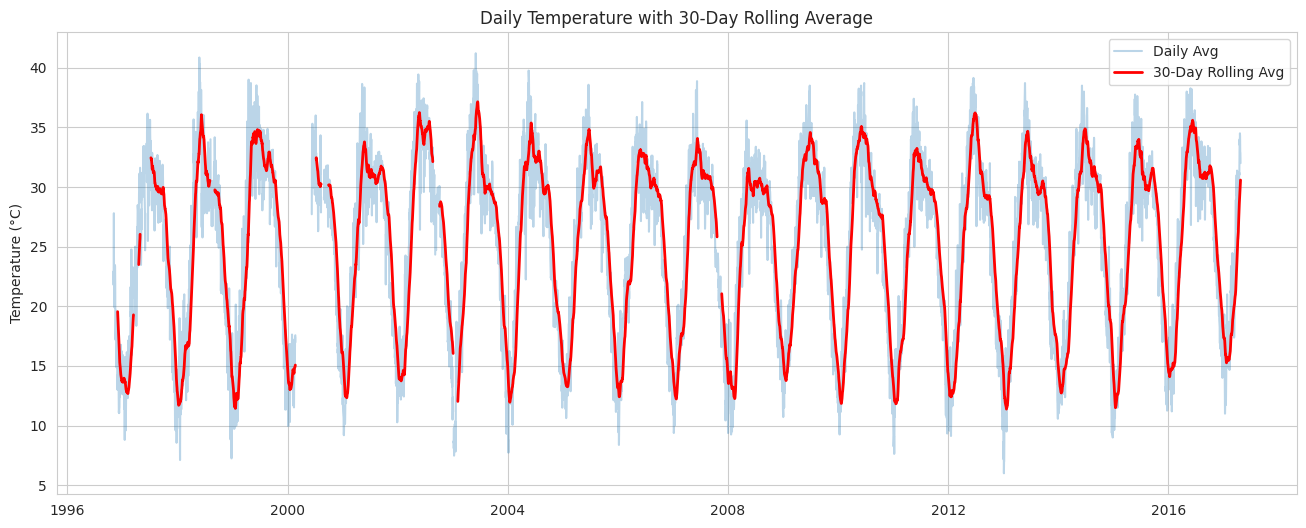

In [24]:
# Rolling 30-day average temperature
daily_temp_df = daily_temp.reset_index()
daily_temp_df['rolling_30d'] = daily_temp_df['temperature'].rolling(window=30).mean()

plt.figure(figsize=(16,6))
plt.plot(daily_temp_df['datetime'], daily_temp_df['temperature'], alpha=0.3, label='Daily Avg')
plt.plot(daily_temp_df['datetime'], daily_temp_df['rolling_30d'], color='red', linewidth=2, label='30-Day Rolling Avg')
plt.title('Daily Temperature with 30-Day Rolling Average')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

**5. Multivariate Analysis**

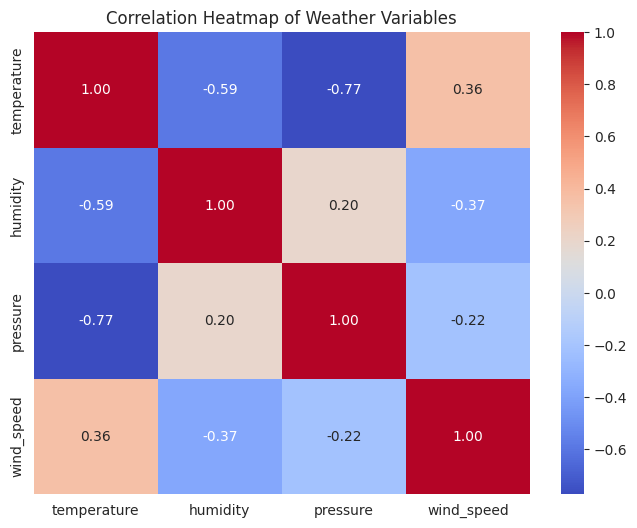

In [25]:
# Correlation heatmap
numeric_cols = ['temperature', 'humidity', 'pressure', 'wind_speed']

plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Weather Variables')
plt.show()

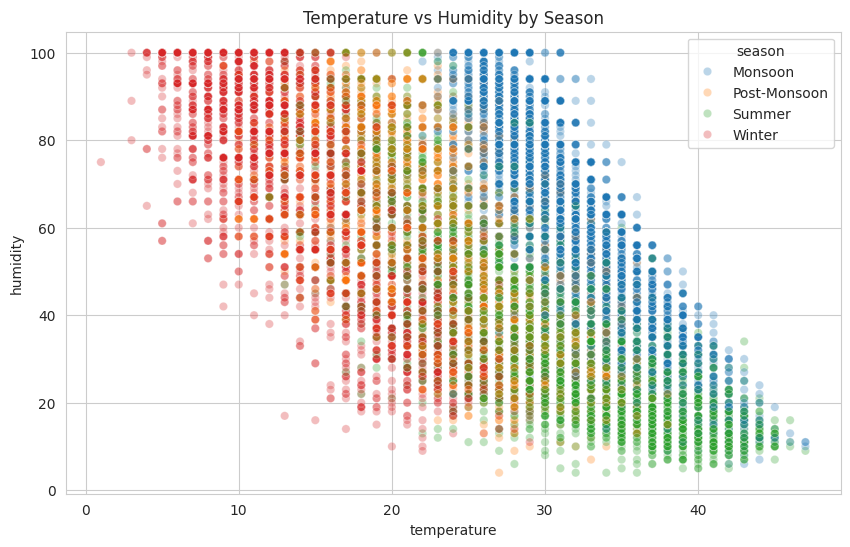

In [26]:
# Temperature vs humidity, colored by season
plt.figure(figsize=(10,6))
sns.scatterplot(data=df.sample(20000, random_state=42), x='temperature', y='humidity', hue='season', alpha=0.3)
plt.title('Temperature vs Humidity by Season')
plt.show()

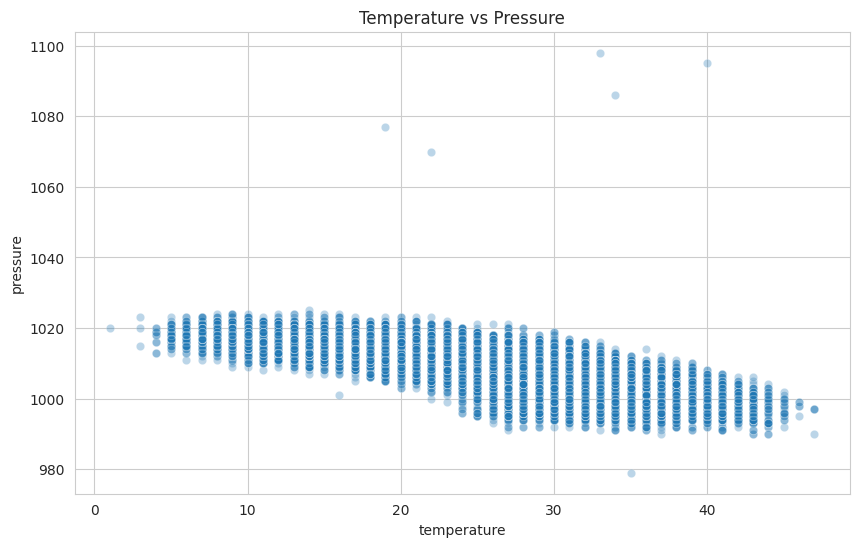

In [27]:
# Pressure vs temperature
plt.figure(figsize=(10,6))
sns.scatterplot(data=df.sample(20000, random_state=42), x='temperature', y='pressure', alpha=0.3)
plt.title('Temperature vs Pressure')
plt.show()

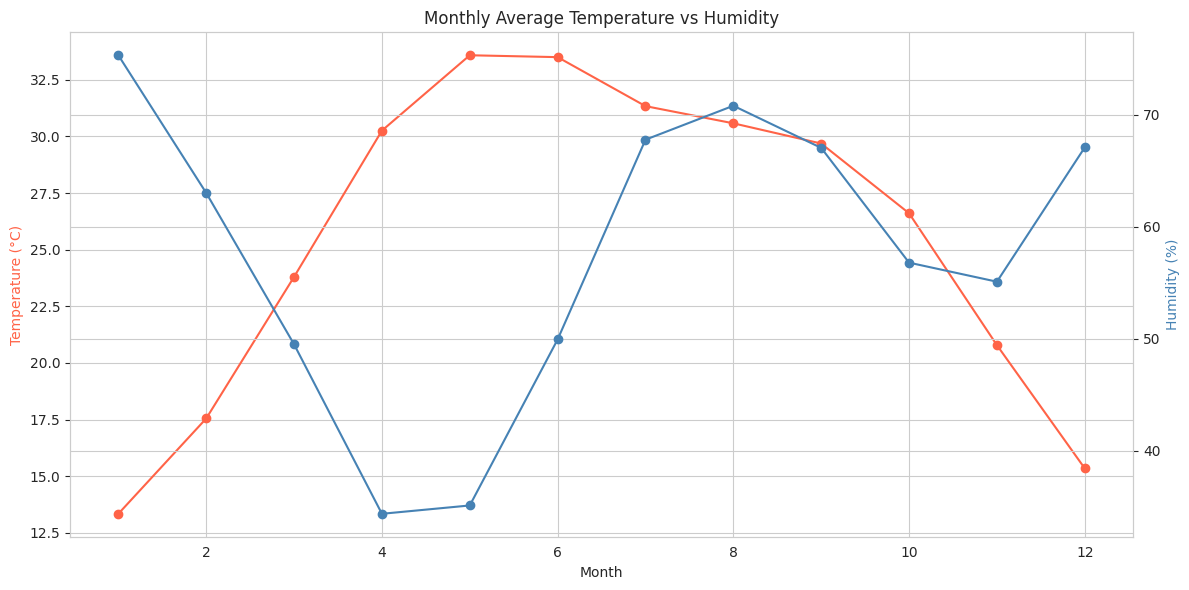

In [28]:
# Monthly average of temperature and humidity together
monthly_avg = df.groupby('month')[['temperature', 'humidity']].mean()

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(monthly_avg.index, monthly_avg['temperature'], color='tomato', marker='o', label='Temperature')
ax1.set_ylabel('Temperature (°C)', color='tomato')
ax1.set_xlabel('Month')

ax2 = ax1.twinx()
ax2.plot(monthly_avg.index, monthly_avg['humidity'], color='steelblue', marker='o', label='Humidity')
ax2.set_ylabel('Humidity (%)', color='steelblue')

plt.title('Monthly Average Temperature vs Humidity')
fig.tight_layout()
plt.show()

**6. Insights Summary**

## Key Insights

- Temperature follows a clear seasonal cycle, peaking in [month(s)] (Summer) and dropping lowest in [month(s)] (Winter).
- The Monsoon season shows [higher/lower] humidity compared to other seasons, as expected.
- Temperature and humidity show a [negative/positive] correlation — hotter periods tend to be [drier/more humid] in this region.
- The 30-day rolling average smooths out daily fluctuations and reveals a clear annual cycle without noise.
- Year-over-year average temperature shows [a slight warming trend / relatively stable pattern] across the recorded years — worth flagging as an observation rather than a definitive climate conclusion given the limited time span.
- Pressure and temperature show [a weak/moderate] relationship, consistent with general meteorological patterns.
- [Add 1-2 more insights specific to what you observed]